<a href="https://colab.research.google.com/github/insarov2014/Toronto-Island-Ferry-Ticket-Counts-Forecast/blob/main/Copy_of_SalesCount_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Toronto Ferry Activity

In [1]:
import numpy as np
import pandas as pd
import time
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


# Part 1: Initial review of the time series data

# Import the time series data

In [3]:
def load_data(file):
    # generic data processing function
    df = pd.read_csv(file,
                dtype={'_id':int, 'Sales Count': int, 'Sales Count':int},
                parse_dates=['Timestamp'])
    df.sort_values('Timestamp', inplace=True)
    # convert to time-aware
    df.set_index('Timestamp', inplace=True)
    df_daily = df.resample('d').sum()
    # engineer some time features
    df_daily['monthly'] = df_daily.reset_index().Timestamp.dt.month.values
    df_daily['quarter'] = df_daily.reset_index().Timestamp.dt.quarter.values
    return df_daily

In [4]:
file = "/content/gdrive/My Drive/Colab Notebooks/Toronto_Ferry_Activity/Toronto Island Ferry Ticket Counts.csv"
df = load_data(file)

In [5]:
# What does the data look like?
df.head()

,_id,Redemption Count,Sales Count,monthly,quarter
Timestamp,,,,,
2015-05-01,985646,1,4,5,2
2015-05-02,0,0,0,5,2
2015-05-03,0,0,0,5,2
2015-05-04,4681600,12,75,5,2
2015-05-05,11332905,537,549,5,2


In [6]:
df.tail()

,_id,Redemption Count,Sales Count,monthly,quarter
Timestamp,,,,,
2025-06-02,25517,4869,5409,6,2
2025-06-03,19480,5541,5503,6,2
2025-06-04,13080,5806,5423,6,2
2025-06-05,6401,2573,2919,6,2
2025-06-06,1225,4505,4269,6,2


In [7]:
# Any missing values?
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3690 entries, 2015-05-01 to 2025-06-06
Freq: D
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   _id               3690 non-null   int64
 1   Redemption Count  3690 non-null   int64
 2   Sales Count       3690 non-null   int64
 3   monthly           3690 non-null   int32
 4   quarter           3690 non-null   int32
dtypes: int32(2), int64(3)
memory usage: 144.1 KB


No missing values exist in the data.

In [9]:
# Any duplicates?
df[df.duplicated()==True]

,_id,Redemption Count,Sales Count,monthly,quarter
Timestamp,,,,,
2015-05-03,0,0,0,5,2
2021-02-22,0,0,0,2,1
2025-01-26,0,0,0,1,1


The 3 records are not duplicates indeed as their time stamps are different.

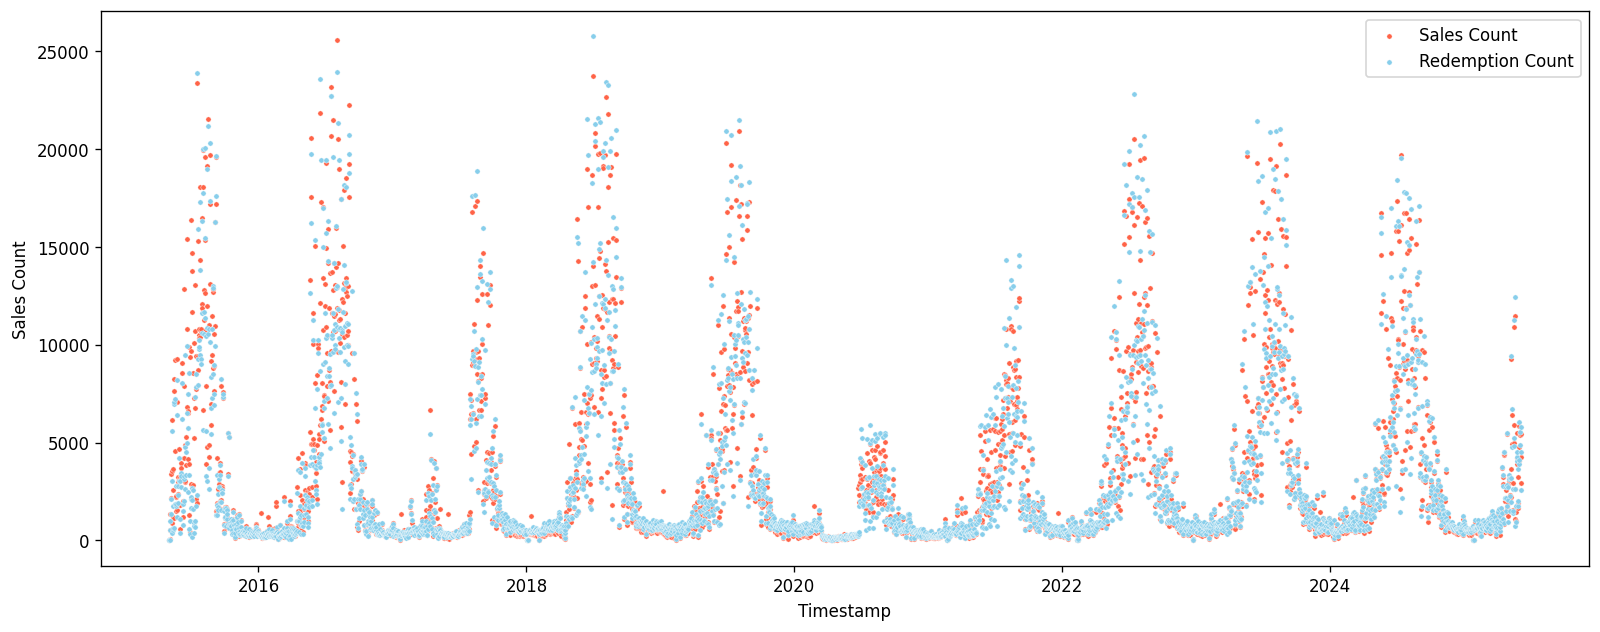

In [10]:
# Plot the data
plt.rcParams.update({'figure.figsize':(16,6), 'figure.dpi':120})
sns.scatterplot(x=df.index, y=df['Sales Count'], s=10, c='tomato', label='Sales Count')
sns.scatterplot(x=df.index, y=df['Redemption Count'], s=10, c='skyblue', label='Redemption Count')
plt.show()

It seems 'Redemption Count' and	'Sales Count' are correlated. Let's calculate corrlation coefficient.

In [11]:
print("The correlation coefficient of Sales Count and Redemption Count is:", round(df['Sales Count'].corr(df['Redemption Count']), 2))

The correlation coefficient of Sales Count and Redemption Count is: 0.98


# Focus on Sales Count data

In [24]:
from sklearn.ensemble import IsolationForest

In [38]:
# to identify outliers
iso = IsolationForest(contamination=0.05, random_state=42)
yhat = iso.fit_predict(pd.DataFrame(df['Sales Count']))
mask = yhat != -1

In [39]:
outliers_indices = list(item for item in np.where(mask==False)[0])
len(outliers_indices)

182

In [40]:
outliers_set = df.iloc[outliers_indices]

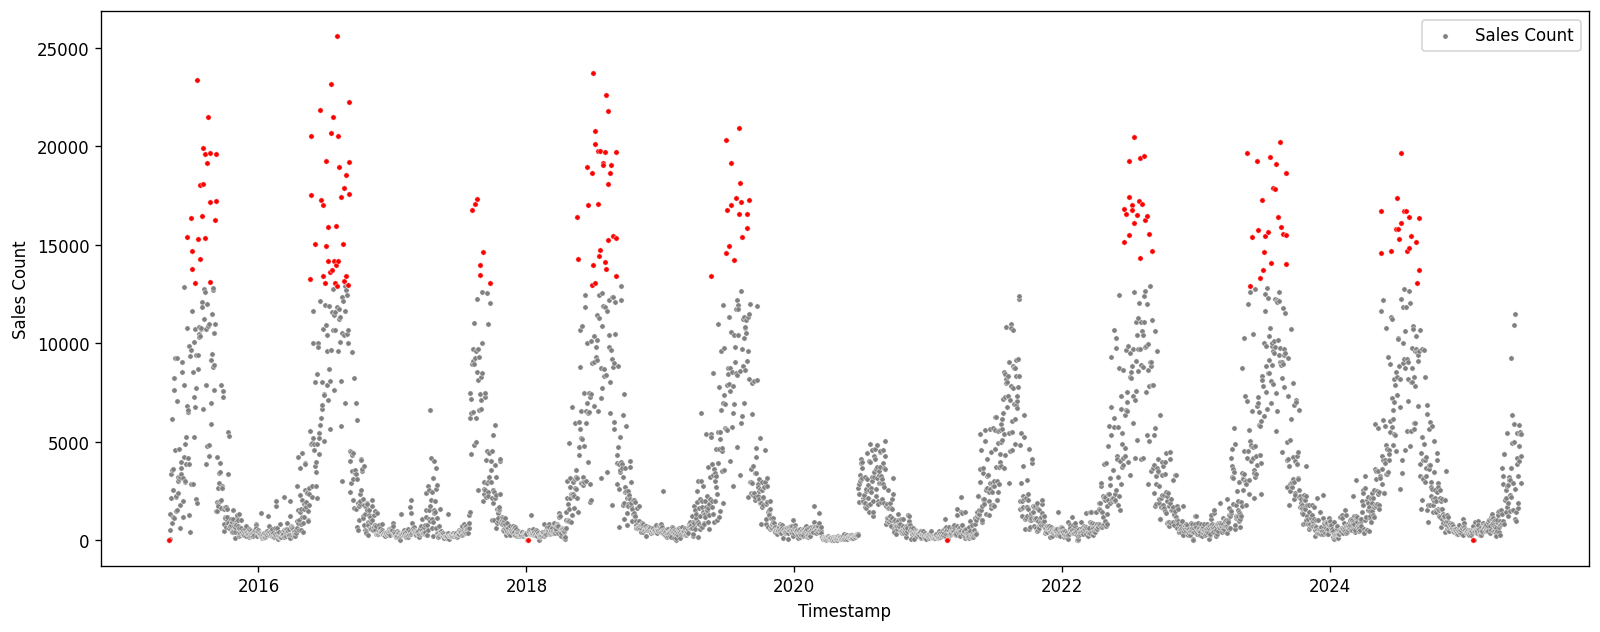

In [41]:
# Plot the data
plt.rcParams.update({'figure.figsize':(16,6), 'figure.dpi':120})
sns.scatterplot(x=df.index, y=df['Sales Count'], s=10, c='grey', label='Sales Count')
sns.scatterplot(x=outliers_set.index, y=outliers_set['Sales Count'], s=10, c='red')
plt.show()

#seasonal_decompose

Recall the scatter plots shows the data repeated themselves every year, I use periods=365.

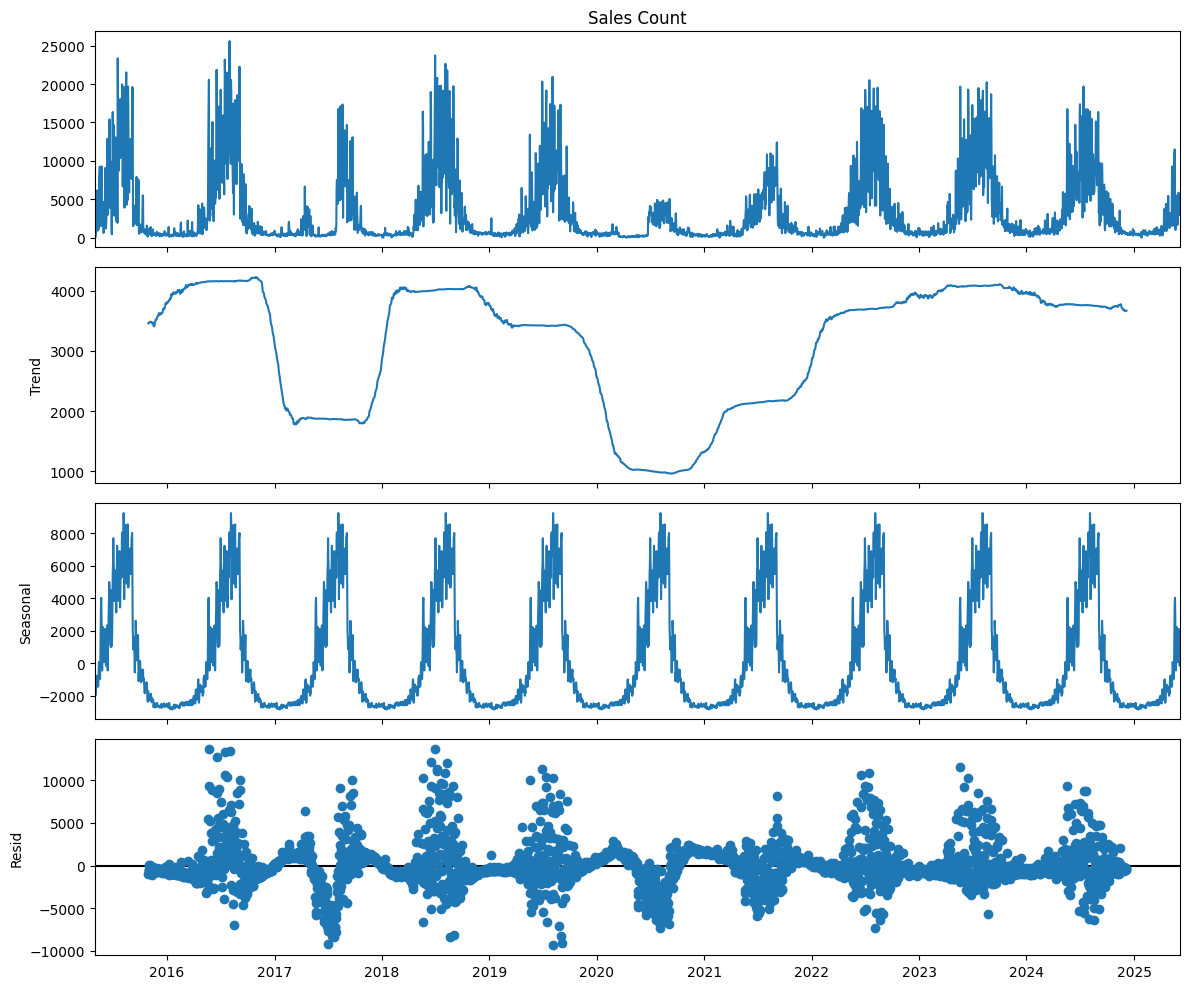

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Additive model
plt.rcParams["figure.figsize"] = (12, 10) # it must be put in the 1st line!
result_add = seasonal_decompose(df['Sales Count'], model='additive', period=365)
result_add.plot()
plt.show()

The trend doesn't show a consistently upward or downward pattern, the seasonal pattern is significant, and the residuals center at 0 with a seasonal pattern.

# Is the data stationary?

In [13]:
#The Augmented Dickey-Fuller Test
#Null Hypothesis: Time Series is non-stationary. It gives a time-dependent trend.
#Alternate Hypothesis: Time Series is stationary. In another term, the series doesn’t depend on time.

from statsmodels.tsa.stattools import adfuller

def Augmented_Dickey_Fuller_Test_func(series , column_name):
    print (f'Dickey-Fuller test results for columns: {column_name}')
    dftest = adfuller(series, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','No Lags Used','Number of observations used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput)
    if dftest[1] <= 0.05:
        print("Conclusion:====>")
        print("Reject the null hypothesis")
        print("The data is stationary")
    else:
        print("Conclusion:====>")
        print("The null hypothesis cannot be rejected")
        print("The data is not stationary")

In [14]:
Augmented_Dickey_Fuller_Test_func(df["Sales Count"],'Sales Count')

Dickey-Fuller test results for columns: Sales Count
Test Statistic                   -4.695517
p-value                           0.000086
No Lags Used                     30.000000
Number of observations used    3659.000000
Critical Value (1%)              -3.432138
Critical Value (5%)              -2.862330
Critical Value (10%)             -2.567191
dtype: float64
Conclusion:====>
Reject the null hypothesis
The data is stationary


#Autocorrelation plots

In [15]:
import statsmodels.api as sm

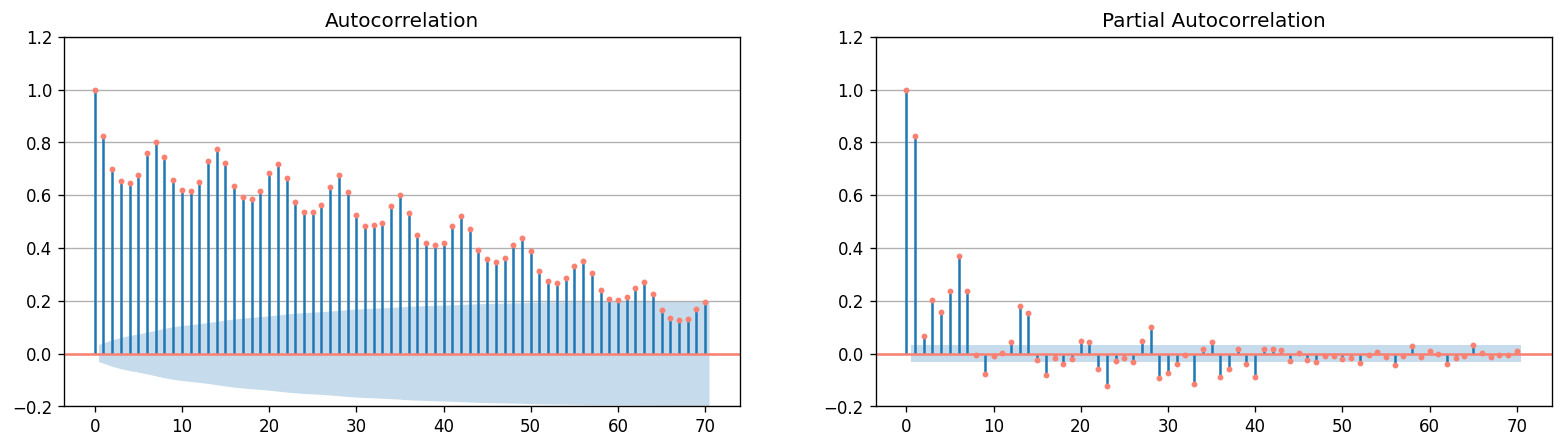

In [16]:
plt.rcParams.update({'figure.figsize':(16,4), 'figure.dpi':120})
fig, axs = plt.subplots(nrows=1, ncols=2)
sm.graphics.tsa.plot_acf(df["Sales Count"], lags=70, ax=axs[0], color="salmon", markersize=2.5)
axs[0].set_title("Autocorrelation")
axs[0].set_ylim(-0.2, 1.2)
axs[0].grid(axis="y")
sm.graphics.tsa.plot_pacf(df["Sales Count"], lags=70, ax=axs[1], color="salmon", markersize=2.5)
axs[1].set_title('Partial Autocorrelation')
axs[1].set_ylim(-0.2, 1.2)
axs[1].grid(axis="y")
fig.show()

The ACF plot reveals a very slowly decaying pattern, indicating a potential seasonality in the data.

The PACF shows that there is a significant spike at the lags 1 and much lower spikes for the subsequent lags. Thus, an AR(1) model would be feasible for the data.

#log tranformation

In [8]:
df['Sales Count'].tail()

,Sales Count
Timestamp,
2025-06-02,5409
2025-06-03,5503
2025-06-04,5423
2025-06-05,2919
2025-06-06,4269


In [9]:
df['Sales Count'].head()

,Sales Count
Timestamp,
2015-05-01,4
2015-05-02,0
2015-05-03,0
2015-05-04,75
2015-05-05,549


I am going to take log for 'Sales Count', since this column contains some zeroes, I would like to add 4 to the 0 records, hence I won't get inf after log transformation.

In [10]:
full_data = df.copy()
full_data['Sales Count'] = np.where(full_data['Sales Count']==0, np.log(full_data['Sales Count']+4), np.log(full_data['Sales Count']))
full_data.head()

,_id,Redemption Count,Sales Count,monthly,quarter
Timestamp,,,,,
2015-05-01,985646,1,1.386294,5,2
2015-05-02,0,0,1.386294,5,2
2015-05-03,0,0,1.386294,5,2
2015-05-04,4681600,12,4.317488,5,2
2015-05-05,11332905,537,6.308098,5,2


In [11]:
full_data.tail()

,_id,Redemption Count,Sales Count,monthly,quarter
Timestamp,,,,,
2025-06-02,25517,4869,8.595820,6,2
2025-06-03,19480,5541,8.613049,6,2
2025-06-04,13080,5806,8.598404,6,2
2025-06-05,6401,2573,7.978996,6,2
2025-06-06,1225,4505,8.359135,6,2


# Part 2: Baselines

# The basic models

#Step 1: Split train set and test set for Sales Count data

Since I don't need to tune hyperparameters manually, I don't need a validation set. Thus, I split the whole data into two sets: train set and test set.

In [12]:
df_new = full_data['Sales Count'].copy().reset_index()
df_new['unique_id'] = 1
df_new.columns = ['ds', 'y', 'unique_id']
df_new

,ds,y,unique_id
0,2015-05-01,1.386294,1
1,2015-05-02,1.386294,1
2,2015-05-03,1.386294,1
3,2015-05-04,4.317488,1
4,2015-05-05,6.308098,1
...,...,...,...
3685,2025-06-02,8.595820,1
3686,2025-06-03,8.613049,1
3687,2025-06-04,8.598404,1
3688,2025-06-05,7.978996,1


In [13]:
tr = df_new.iloc[:-365].copy()
tr

,ds,y,unique_id
0,2015-05-01,1.386294,1
1,2015-05-02,1.386294,1
2,2015-05-03,1.386294,1
3,2015-05-04,4.317488,1
4,2015-05-05,6.308098,1
...,...,...,...
3320,2024-06-02,8.126814,1
3321,2024-06-03,8.490438,1
3322,2024-06-04,8.442901,1
3323,2024-06-05,8.120291,1


In [14]:
te = df_new.iloc[-365:].copy()
te

,ds,y,unique_id
3325,2024-06-07,8.157084,1
3326,2024-06-08,9.140990,1
3327,2024-06-09,8.430763,1
3328,2024-06-10,8.311890,1
3329,2024-06-11,8.386401,1
...,...,...,...
3685,2025-06-02,8.595820,1
3686,2025-06-03,8.613049,1
3687,2025-06-04,8.598404,1
3688,2025-06-05,7.978996,1


In [15]:
print("Min tr Date: " , tr.ds.min())
print("Max tr Date: " , tr.ds.max())
print("Min te Date: " , te.ds.min())
print("Max te Date: " , te.ds.max())

Min tr Date:  2015-05-01 00:00:00
Max tr Date:  2024-06-06 00:00:00
Min te Date:  2024-06-07 00:00:00
Max te Date:  2025-06-06 00:00:00


# Step 2: Try multiple methods of StatsForecast from NIXTLA

In [15]:
pip install statsforecast

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.8/344.8 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.4/287.4 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.3/135.3 kB 11.0 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.1
    Uninstalling scipy-1.16.1:
      Successfully uninstalled scipy-1.16.1


In [16]:
import statsforecast
from statsforecast.core import StatsForecast

In [17]:
from statsforecast.models import (
    Naive,
    SeasonalNaive,
    WindowAverage,
    HoltWinters,
    AutoETS,
    ARIMA,
    AutoTheta,
    DynamicTheta,
    DynamicOptimizedTheta,
    Theta,
    OptimizedTheta,
    TBATS,
    AutoTBATS,
    MSTL
)

In [18]:
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import root_mean_squared_error as rmse

In [19]:
def evaluate_performance(ts_train, ts_test, models, metrics, freq, level, id_col, time_col, target_col, h, metric_df=None):
    if metric_df is None:
        metric_df = pd.DataFrame()  # Initialize an empty DataFrame if not provided

    results = ts_test.copy()

    # Timing dictionary to store train and predict durations
    timing = {}

    for model in models:
        model_name = model.__class__.__name__
        evaluation = {}  # Reset the evaluation dictionary for each model

        # Start the timer for fitting and prediction
        start_time = time.time()

        # Instantiate StatsForecast class
        sf = StatsForecast(
            models=[model],
            freq=freq,
            n_jobs=-1,
            fallback_model=Naive()
        )

        # Efficiently predict without storing memory
        y_pred = sf.forecast(
            h=h,
            df=ts_train,
            id_col=id_col,
            time_col=time_col,
            target_col=target_col,
            level=level,
        )

        # Calculating the duration
        duration = time.time() - start_time
        timing[model_name] = duration

        # Merge prediction results to the original dataframe
        results = results.merge(y_pred, how='left', on=[id_col, time_col])

        ids = ts_train[id_col].unique()
        # Calculate metrics
        for id in ids:
            temp_results = results[results[id_col] == id]
            temp_train = ts_train[ts_train[id_col] == id]
            for metric in metrics:
                metric_name = metric.__name__
                if metric_name == 'mase':
                    evaluation[metric_name] = metric(temp_results[target_col].values,
                                                    temp_results[model_name].values,
                                                    temp_train[target_col].values, seasonality=365)
                else:
                    evaluation[metric_name] = metric(temp_results[target_col].values, temp_results[model_name].values)
            evaluation[id_col] = id
            evaluation['Time Elapsed'] = timing[model_name]

            # Prepare and append this model's results to metric_df
            temp_df = pd.DataFrame(evaluation, index=[0])
            temp_df['Model'] = model_name
            metric_df = pd.concat([metric_df, temp_df], ignore_index=True)

    return results, metric_df

In [20]:
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from itertools import cycle

In [21]:
def format_plot(fig, legends = None, xlabel="Time", ylabel="Value", title="", font_size=15):
    if legends:
        names = cycle(legends)
        fig.for_each_trace(lambda t:  t.update(name = next(names)))
    fig.update_layout(
            autosize=False,
            width=900,
            height=500,
            title_text=title,
            title={
            'x':0.5,
            'xanchor': 'center',
            'yanchor': 'top'},
            titlefont={
                "size": 15
            },
            legend_title = None,
            legend=dict(
                font=dict(size=font_size),
                orientation="h",
                yanchor="bottom",
                y=0.98,
                xanchor="right",
                x=1,
            ),
            yaxis=dict(
                title_text=ylabel,
                titlefont=dict(size=font_size),
                tickfont=dict(size=font_size),
            ),
            xaxis=dict(
                title_text=xlabel,
                titlefont=dict(size=font_size),
                tickfont=dict(size=font_size),
            )
        )
    return fig

In [22]:
import plotly.express as px

def plot_forecast(pred_df, forecast_columns, timestamp_col, forecast_display_names=None):
    if forecast_display_names is None:
        forecast_display_names = forecast_columns
    else:
        assert len(forecast_columns) == len(forecast_display_names)

    mask = ~pred_df[forecast_columns[0]].isnull()
    colors = [c.replace("rgb", "rgba").replace(")", ", <alpha>)") for c in px.colors.qualitative.Dark2]
    act_color = colors[0]
    colors = cycle(colors[1:])
    dash_types = cycle(["dash", "dot", "dashdot"])

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=pred_df[mask][timestamp_col], y=pred_df[mask]['y'],
                             mode='lines', line=dict(color=act_color.replace("<alpha>", "0.3")),
                             name='Actual y'))

    for col, display_col in zip(forecast_columns, forecast_display_names):
        fig.add_trace(go.Scatter(x=pred_df[mask][timestamp_col], y=pred_df.loc[mask, col],
                                 mode='lines', line=dict(dash=next(dash_types), color=next(colors).replace("<alpha>", "1")),
                                 name=display_col))
    return fig

#Naive (Baseline)

In [25]:
metrics = pd.DataFrame()

results, metrics = evaluate_performance(
    ts_train=tr,
    ts_test=te,
    models=[Naive()],
    metrics=[mape, mae, mse, rmse],
    freq='D',
    level=[],  # Ensure this is correct or adjust as necessary
    id_col='unique_id',
    time_col='ds',
    target_col='y',
    h=len(te),
    metric_df=metrics  # Pass None or an existing DataFrame if you want to append results
)

In [26]:
results.head(3)

,ds,y,unique_id,Naive
0,2024-06-07,8.157084,1,8.446771
1,2024-06-08,9.140990,1,8.446771
2,2024-06-09,8.430763,1,8.446771


In [27]:
results.tail(3)

,ds,y,unique_id,Naive
362,2025-06-04,8.598404,1,8.446771
363,2025-06-05,7.978996,1,8.446771
364,2025-06-06,8.359135,1,8.446771


In [28]:
metrics

,mean_absolute_percentage_error,mean_absolute_error,mean_squared_error,root_mean_squared_error,unique_id,Time Elapsed,Model
0,0.209422,1.269842,2.432177,1.559544,1,0.072543,Naive


In [29]:
def compare_plot(results, forecast_columns, forecast_display_names, timestamp_col):
    fig = plot_forecast(results, forecast_columns=model_name, forecast_display_names=model_display_name, timestamp_col='ds')
    fig = format_plot(fig, title=f"{model_name[0]}: "\
                      f"mape: {metrics.loc[metrics.Model==model_name[0]][['mean_absolute_percentage_error']].iloc[0].item():.2e} | "\
                      f"mae: {metrics.loc[metrics.Model==model_name[0]][['mean_absolute_error']].iloc[0].item():.2e} | "\
                      f"mse: {metrics.loc[metrics.Model==model_name[0]][['mean_squared_error']].iloc[0].item():.2e} | "\
                      f"rmse: {metrics.loc[metrics.Model==model_name[0]][['root_mean_squared_error']].iloc[0].item():.2e}")
    fig.update_xaxes(type="date", range=["2024-06-07", "2025-06-06"])
    fig.show()

model_name = ['Naive']
model_display_name = ['Naive']
compare_plot(results, model_name, model_display_name, timestamp_col='ds')

# Seasonal Naive

In [30]:
results, metrics = evaluate_performance(
    ts_train=tr,
    ts_test=te,
    models=[SeasonalNaive(season_length=365)],
    #metrics=[mase, mae, mse, rmse, smape, forecast_bias],
    metrics=[mape, mae, mse, rmse],
    freq='D',
    level=[],  # Ensure this is correct or adjust as necessary
    id_col='unique_id',
    time_col='ds',
    target_col='y',
    h=len(te),
    metric_df=metrics  # Pass None or an existing DataFrame if you want to append results
)

In [31]:
results.head(3)

,ds,y,unique_id,SeasonalNaive
0,2024-06-07,8.157084,1,7.666222
1,2024-06-08,9.140990,1,8.137688
2,2024-06-09,8.430763,1,9.453208


In [32]:
results.tail(3)

,ds,y,unique_id,SeasonalNaive
362,2025-06-04,8.598404,1,8.442901
363,2025-06-05,7.978996,1,8.120291
364,2025-06-06,8.359135,1,8.446771


In [33]:
model_name = ['SeasonalNaive']
model_display_name = ['SeasonalNaive']
compare_plot(results, model_name, model_display_name, timestamp_col='ds')

#WindowAverage

In [34]:
%%time
results, metrics = evaluate_performance(
    ts_train=tr,
    ts_test=te,
    models=[WindowAverage(window_size = 365)],
    #metrics=[mase, mae, mse, rmse, smape, forecast_bias],
    metrics=[mape, mae, mse, rmse],
    freq='D',
    level=[],  # Ensure this is correct or adjust as necessary
    id_col='unique_id',
    time_col='ds',
    target_col='y',
    h=len(te),
    metric_df=metrics  # Pass None or an existing DataFrame if you want to append results
)

CPU times: user 41 ms, sys: 49 µs, total: 41 ms
Wall time: 41.6 ms


In [35]:
results.head(3)

,ds,y,unique_id,WindowAverage
0,2024-06-07,8.157084,1,7.61565
1,2024-06-08,9.140990,1,7.61565
2,2024-06-09,8.430763,1,7.61565


In [36]:
results.tail(3)

,ds,y,unique_id,WindowAverage
362,2025-06-04,8.598404,1,7.61565
363,2025-06-05,7.978996,1,7.61565
364,2025-06-06,8.359135,1,7.61565


In [37]:
model_name = ['WindowAverage']
model_display_name = ['WindowAverage']
compare_plot(results, model_name, model_display_name, timestamp_col='ds')

#HoltWinters

In [38]:
%%time
results, metrics = evaluate_performance(
    ts_train=tr,
    ts_test=te,
    models=[HoltWinters(error_type = 'A', season_length = 365)],
    #metrics=[mase, mae, mse, rmse, smape, forecast_bias],
    metrics=[mape, mae, mse, rmse],
    freq='D',
    level=[],  # Ensure this is correct or adjust as necessary
    id_col='unique_id',
    time_col='ds',
    target_col='y',
    h=len(te),
    metric_df=metrics  # Pass None or an existing DataFrame if you want to append results
)

CPU times: user 10.6 s, sys: 71.4 ms, total: 10.6 s
Wall time: 10.2 s


In [39]:
results.head(3)

,ds,y,unique_id,HoltWinters
0,2024-06-07,8.157084,1,8.084927
1,2024-06-08,9.140990,1,8.145281
2,2024-06-09,8.430763,1,8.452685


In [40]:
results.tail(3)

,ds,y,unique_id,HoltWinters
362,2025-06-04,8.598404,1,8.368793
363,2025-06-05,7.978996,1,8.123539
364,2025-06-06,8.359135,1,8.106000


In [41]:
model_name = ['HoltWinters']
model_display_name = ['HoltWinters']
compare_plot(results, model_name, model_display_name, timestamp_col='ds')

#Auto ETS

In [42]:
%%time
# Auto ETS
results, metrics = evaluate_performance(
    ts_train=tr,
    ts_test=te,
    models=[AutoETS(model = 'AAA',season_length = 365)],
    #metrics=[mase, mae, mse, rmse, smape, forecast_bias],
    metrics=[mape, mae, mse, rmse],
    freq='D',
    level=[],  # Ensure this is correct or adjust as necessary
    id_col='unique_id',
    time_col='ds',
    target_col='y',
    h=len(te),
    metric_df=metrics  # Pass None or an existing DataFrame if you want to append results
)

CPU times: user 10.4 s, sys: 52.1 ms, total: 10.4 s
Wall time: 9.81 s


In [43]:
results.head(3)

,ds,y,unique_id,AutoETS
0,2024-06-07,8.157084,1,8.084927
1,2024-06-08,9.140990,1,8.145281
2,2024-06-09,8.430763,1,8.452685


In [44]:
results.tail(3)

,ds,y,unique_id,AutoETS
362,2025-06-04,8.598404,1,8.368793
363,2025-06-05,7.978996,1,8.123539
364,2025-06-06,8.359135,1,8.106000


In [45]:
model_name = ['AutoETS']
model_display_name = ['AutoETS']

compare_plot(results, model_name, model_display_name, timestamp_col='ds')

# ARIMA crashed!!!

In [ ]:
# %%time
# results, metrics = evaluate_performance(
#     ts_train=tr,
#     ts_test=te,
#     models=[ARIMA(order = (1,0,0), seasonal_order = (1,0,0), season_length = 365)],
#     metrics=[mape, mae, mse, rmse],
#     freq='D',
#     level=[],  # Ensure this is correct or adjust as necessary
#     id_col='unique_id',
#     time_col='ds',
#     target_col='y',
#     h=len(te),
#     metric_df=metrics  # Pass None or an existing DataFrame if you want to append results
# )

Note: Google Colab doesn't allow me to obtain the result of ARIMA.

Will try ARIMA or SARIMA later.

# MSTL

In [46]:
%%time
results, metrics = evaluate_performance(
    ts_train=tr,
    ts_test=te,
    models=[MSTL(season_length = 365)],
    #metrics=[mase, mae, mse, rmse, smape, forecast_bias],
    metrics=[mape, mae, mse, rmse],
    freq='D',
    level=[],  # Ensure this is correct or adjust as necessary
    id_col='unique_id',
    time_col='ds',
    target_col='y',
    h=len(te),
    metric_df=metrics  # Pass None or an existing DataFrame if you want to append results
)

CPU times: user 1.91 s, sys: 2.92 ms, total: 1.92 s
Wall time: 3.48 s


In [47]:
results.head(3)

,ds,y,unique_id,MSTL
0,2024-06-07,8.157084,1,8.183910
1,2024-06-08,9.140990,1,8.190125
2,2024-06-09,8.430763,1,8.623140


In [48]:
results.tail(3)

,ds,y,unique_id,MSTL
362,2025-06-04,8.598404,1,8.637352
363,2025-06-05,7.978996,1,8.285859
364,2025-06-06,8.359135,1,8.265520


In [49]:
model_name = ['MSTL']
model_display_name = ['MSTL']

compare_plot(results, model_name, model_display_name, timestamp_col='ds')

# Theta

In [50]:
%%time
results, metrics = evaluate_performance(
    ts_train=tr,
    ts_test=te,
    models=[Theta(season_length=365, decomposition_type='additive')],
    #metrics=[mase, mae, mse, rmse, smape, forecast_bias],
    metrics=[mape, mae, mse, rmse],
    freq='D',
    level=[],  # Ensure this is correct or adjust as necessary
    id_col='unique_id',
    time_col='ds',
    target_col='y',
    h=len(te),
    metric_df=metrics  # Pass None or an existing DataFrame if you want to append results
)

CPU times: user 1.13 s, sys: 1.21 ms, total: 1.13 s
Wall time: 1.13 s


In [51]:
results.head(3)

,ds,y,unique_id,Theta
0,2024-06-07,8.157084,1,8.387647
1,2024-06-08,9.140990,1,8.415110
2,2024-06-09,8.430763,1,8.737539


In [52]:
results.tail(3)

,ds,y,unique_id,Theta
362,2025-06-04,8.598404,1,8.559780
363,2025-06-05,7.978996,1,8.390885
364,2025-06-06,8.359135,1,8.339855


In [53]:
model_name = ['Theta']
model_display_name = ['Theta']

compare_plot(results, model_name, model_display_name, timestamp_col='ds')

#TBATS

In [54]:
%%time
results, metrics = evaluate_performance(
    ts_train=tr,
    ts_test=te,
    models=[TBATS([365])],
    #metrics=[mase, mae, mse, rmse, smape, forecast_bias],
    metrics=[mape, mae, mse, rmse],
    freq='D',
    level=[],  # Ensure this is correct or adjust as necessary
    id_col='unique_id',
    time_col='ds',
    target_col='y',
    h=len(te),
    metric_df=metrics  # Pass None or an existing DataFrame if you want to append results
)

CPU times: user 7.97 s, sys: 577 ms, total: 8.55 s
Wall time: 8.37 s


In [55]:
results.head(3)

,ds,y,unique_id,TBATS
0,2024-06-07,8.157084,1,8.380257
1,2024-06-08,9.140990,1,8.383143
2,2024-06-09,8.430763,1,8.386323


In [56]:
results.tail(3)

,ds,y,unique_id,TBATS
362,2025-06-04,8.598404,1,12.273403
363,2025-06-05,7.978996,1,12.275325
364,2025-06-06,8.359135,1,12.277578


In [57]:
model_name = ['TBATS']
model_display_name = ['TBATS']

compare_plot(results, model_name, model_display_name, timestamp_col='ds')

#Dynamic Optimized Theta

In [58]:
%%time
results, metrics = evaluate_performance(
    ts_train=tr,
    ts_test=te,
    models=[DynamicOptimizedTheta(season_length=365, decomposition_type="additive")],
    #metrics=[mase, mae, mse, rmse, smape, forecast_bias],
    metrics=[mape, mae, mse, rmse],
    freq='D',
    level=[],  # Ensure this is correct or adjust as necessary
    id_col='unique_id',
    time_col='ds',
    target_col='y',
    h=len(te),
    metric_df=metrics  # Pass None or an existing DataFrame if you want to append results
)

CPU times: user 3.11 s, sys: 14.1 ms, total: 3.13 s
Wall time: 3.18 s


In [59]:
results.head(3)

,ds,y,unique_id,DynamicOptimizedTheta
0,2024-06-07,8.157084,1,8.387687
1,2024-06-08,9.140990,1,8.415116
2,2024-06-09,8.430763,1,8.737510


In [60]:
results.tail(3)

,ds,y,unique_id,DynamicOptimizedTheta
362,2025-06-04,8.598404,1,8.550724
363,2025-06-05,7.978996,1,8.381812
364,2025-06-06,8.359135,1,8.330764


In [61]:
model_name = ['DynamicOptimizedTheta']
model_display_name = ['DynamicOptimizedTheta']
compare_plot(results, model_name, model_display_name, timestamp_col='ds')

# Optimized Theta

In [62]:
%%time
results, metrics = evaluate_performance(
    ts_train=tr,
    ts_test=te,
    models=[OptimizedTheta(season_length=365, decomposition_type="additive")],
    #metrics=[mase, mae, mse, rmse, smape, forecast_bias],
    metrics=[mape, mae, mse, rmse],
    freq='D',
    level=[],  # Ensure this is correct or adjust as necessary
    id_col='unique_id',
    time_col='ds',
    target_col='y',
    h=len(te),
    metric_df=metrics  # Pass None or an existing DataFrame if you want to append results
)

CPU times: user 2.96 s, sys: 6.57 ms, total: 2.96 s
Wall time: 2.96 s


In [63]:
results.head(3)

,ds,y,unique_id,OptimizedTheta
0,2024-06-07,8.157084,1,8.387776
1,2024-06-08,9.140990,1,8.415301
2,2024-06-09,8.430763,1,8.737791


In [64]:
results.tail(3)

,ds,y,unique_id,OptimizedTheta
362,2025-06-04,8.598404,1,8.582024
363,2025-06-05,7.978996,1,8.413191
364,2025-06-06,8.359135,1,8.362222


In [65]:
model_name = ['OptimizedTheta']
model_display_name = ['OptimizedTheta']

compare_plot(results, model_name, model_display_name, timestamp_col='ds')

# Step 3: Comparison

In [66]:
metrics

,mean_absolute_percentage_error,mean_absolute_error,mean_squared_error,root_mean_squared_error,unique_id,Time Elapsed,Model
0,0.209422,1.269842,2.432177,1.559544,1,0.072543,Naive
1,0.086879,0.515693,0.532573,0.729776,1,0.056352,SeasonalNaive
2,0.166255,1.074257,1.597177,1.263795,1,0.034636,WindowAverage
3,0.081098,0.470508,0.461180,0.679102,1,10.172288,HoltWinters
4,0.081098,0.470508,0.461180,0.679102,1,9.804001,AutoETS
5,0.085952,0.500742,0.509808,0.714008,1,3.470846,MSTL
6,0.097880,0.575848,0.615149,0.784315,1,1.126477,Theta
7,0.392565,2.515619,9.343065,3.056643,1,8.360339,TBATS
8,0.097437,0.573119,0.610896,0.781599,1,3.170371,DynamicOptimizedTheta
9,0.098884,0.582044,0.624648,0.790347,1,2.952729,OptimizedTheta


In [67]:
metric_styled = metrics.reset_index(drop=True).style.format({
            "mape": "{:.2e}",
            "mae": "{:.2e}",
            "mse": "{:.2e}",
            "rmse": "{:.2e}"}).highlight_min(color='green', subset=['mean_absolute_percentage_error',
                                                                   'mean_absolute_error',
                                                                   'mean_squared_error',
                                                                   'root_mean_squared_error'])
display(metric_styled)

,mean_absolute_percentage_error,mean_absolute_error,mean_squared_error,root_mean_squared_error,unique_id,Time Elapsed,Model
0,0.209422,1.269842,2.432177,1.559544,1,0.072543,Naive
1,0.086879,0.515693,0.532573,0.729776,1,0.056352,SeasonalNaive
2,0.166255,1.074257,1.597177,1.263795,1,0.034636,WindowAverage
3,0.081098,0.470508,0.461180,0.679102,1,10.172288,HoltWinters
4,0.081098,0.470508,0.461180,0.679102,1,9.804001,AutoETS
5,0.085952,0.500742,0.509808,0.714008,1,3.470846,MSTL
6,0.097880,0.575848,0.615149,0.784315,1,1.126477,Theta
7,0.392565,2.515619,9.343065,3.056643,1,8.360339,TBATS
8,0.097437,0.573119,0.610896,0.781599,1,3.170371,DynamicOptimizedTheta
9,0.098884,0.582044,0.624648,0.790347,1,2.952729,OptimizedTheta


Note Holt Winters and AutoETS got the same values for the same metrics, I only consider one of them. Since mape is for comparison for different time series, and recall the data contain many outliers, I would use mean_absolute_error as the metric to decide a chosen model.

I will use Holt Winters as my baseline.

#ARIMA

In [77]:
full_data.shape

(3690, 5)

In [83]:
# to leave the set: from  2024-06-07 to 2025-06-06
cutOff = 3325
toUse = full_data['Sales Count'][:cutOff].copy()
notUsed = full_data['Sales Count'][cutOff:].copy()

time_toUse = full_data.index[:cutOff].copy()
time_notUsed = full_data.index[cutOff:].copy()

print("Min toUse Date: " , time_toUse.min())
print("Max toUse Date: " , time_toUse.max())
print("Min notUsed Date: " , time_notUsed.min())
print("Max notUsed Date: " , time_notUsed.max())

Min toUse Date:  2015-05-01 00:00:00
Max toUse Date:  2024-06-06 00:00:00
Min notUsed Date:  2024-06-07 00:00:00
Max notUsed Date:  2025-06-06 00:00:00


In [86]:
toUse.shape

(3325,)

In [87]:
notUsed.shape

(365,)

In [74]:
from statsmodels.tsa.arima.model import ARIMA

In [129]:
# Fit ARIMA model
model_ARIMA = ARIMA(toUse, order=(1,1,1))
model_fit_ARIMA = model_ARIMA.fit()

In [130]:
print(model_fit_ARIMA.summary())

                               SARIMAX Results                                
Dep. Variable:            Sales Count   No. Observations:                 3325
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2883.410
Date:                Sat, 30 Aug 2025   AIC                           5772.820
Time:                        20:12:41   BIC                           5791.147
Sample:                    05-01-2015   HQIC                          5779.378
                         - 06-06-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4037      0.016     25.360      0.000       0.372       0.435
ma.L1         -0.8493      0.010    -81.072      0.000      -0.870      -0.829
sigma2         0.3318      0.004     77.394      0.0

In [131]:
# Forecast
forecast_ARIMA = model_fit_ARIMA.forecast(steps=365)

In [90]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [91]:
len(notUsed)

365

In [92]:
len(forecast_ARIMA)

365

In [132]:
# Compute the metrics
print(mean_squared_error(notUsed, forecast_ARIMA))
print(mean_absolute_error(notUsed, forecast_ARIMA))

2.38446198245854
1.2586513450616594


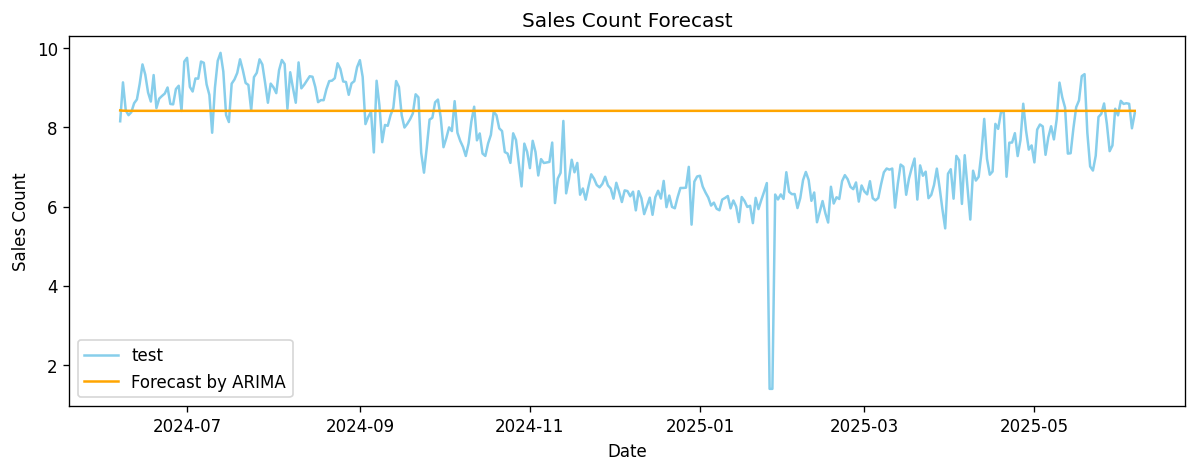

In [133]:
# Plot the results with specified colors
plt.figure(figsize=(12,4))
plt.plot(time_notUsed, notUsed, label='test', color='skyblue')
plt.plot(time_notUsed, forecast_ARIMA, label='Forecast by ARIMA', color='orange')
plt.title('Sales Count Forecast')
plt.xlabel('Date')
plt.ylabel('Sales Count')
plt.legend()
plt.show()

In [100]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [134]:
my_order = (1, 1, 1)
my_seasonal_order = (1, 1, 1, 12)
# define model
model_seasonal = SARIMAX(toUse, order=my_order, seasonal_order=my_seasonal_order)
model_seasonal_fit = model_seasonal.fit()

In [135]:
print(model_seasonal_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                        Sales Count   No. Observations:                 3325
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -2907.182
Date:                            Sat, 30 Aug 2025   AIC                           5824.365
Time:                                    20:13:29   BIC                           5854.891
Sample:                                05-01-2015   HQIC                          5835.290
                                     - 06-06-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4022      0.018     21.889      0.000       0.366       0.438
ma.L1         -0.8478      0.012   

In [136]:
# Forecast
forecast_seasonal = model_seasonal_fit.forecast(steps=365)

In [137]:
# Compute the metrics
print(mean_squared_error(notUsed, forecast_seasonal))
print(mean_absolute_error(notUsed, forecast_seasonal))

3.0220368600548433
1.4325041004225718


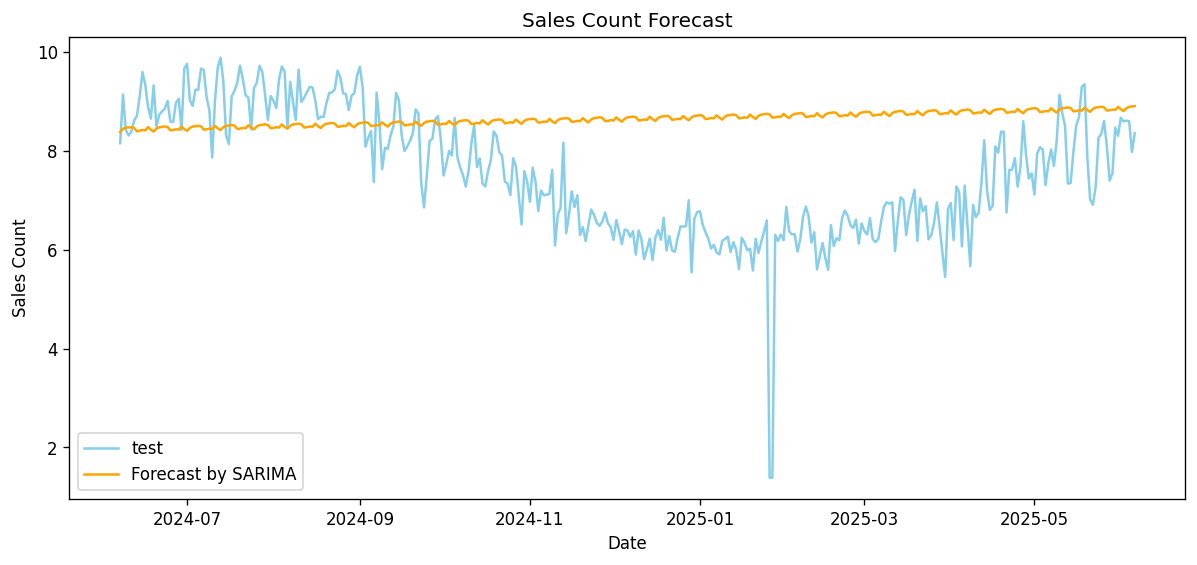

In [138]:
# Plot the results with specified colors
plt.figure(figsize=(12,5))
plt.plot(time_notUsed, notUsed, label='test', color='skyblue')
plt.plot(time_notUsed, forecast_seasonal, label='Forecast by SARIMA', color='orange')
plt.title('Sales Count Forecast')
plt.xlabel('Date')
plt.ylabel('Sales Count')
plt.legend()
plt.show()

The two models don't give better forecasts than Holt Winters does.

# Part 3: Use Machine Learning Methods

In [68]:
full_data.head()

,_id,Redemption Count,Sales Count,monthly,quarter
Timestamp,,,,,
2015-05-01,985646,1,1.386294,5,2
2015-05-02,0,0,1.386294,5,2
2015-05-03,0,0,1.386294,5,2
2015-05-04,4681600,12,4.317488,5,2
2015-05-05,11332905,537,6.308098,5,2


'_id' doesn't provide any useful information, I will drop it.

In [69]:
full_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3690 entries, 2015-05-01 to 2025-06-06
Freq: D
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   _id               3690 non-null   int64  
 1   Redemption Count  3690 non-null   int64  
 2   Sales Count       3690 non-null   float64
 3   monthly           3690 non-null   int32  
 4   quarter           3690 non-null   int32  
dtypes: float64(1), int32(2), int64(2)
memory usage: 144.1 KB


#Feature Engineering

<font color='skyblue'>Temporal embedding

In [70]:
# to create calendar features, the monthly and quarter features were given

df_newFea = full_data.copy().drop(['_id'], axis=1)

df_newFea['Datetime'] = pd.to_datetime(df_newFea.index,format='%d-%m-%Y %H:%M')
df_newFea['year'] = df_newFea['Datetime'].dt.year
df_newFea['day'] = df_newFea['Datetime'].dt.day
df_newFea['dayofweek_num'] = df_newFea['Datetime'].dt.dayofweek

df_newFea.shape

(3690, 8)

In [71]:
df_newFea.head(3)

,Redemption Count,Sales Count,monthly,quarter,Datetime,year,day,dayofweek_num
Timestamp,,,,,,,,
2015-05-01,1,1.386294,5,2,2015-05-01,2015,1,4
2015-05-02,0,1.386294,5,2,2015-05-02,2015,2,5
2015-05-03,0,1.386294,5,2,2015-05-03,2015,3,6


<font color='skyblue'>Time delay embedding

Recall the ACF plot indicates that the current value is strongly related to the historic values, so I create the lag features. I could trace back to lag=7.  

Since the shiftback method will generate NaN, I will impute the group of missing values with the 1st value of 'Sales Count' in the data.

In [72]:
# to create lag features
impute_lags = df_newFea['Sales Count'].iloc[0]
for i in range(1,8):
    df_newFea[f'lag_{i}'] = df_newFea['Sales Count'].shift(i)
    df_newFea[f'lag_{i}'].fillna(impute_lags, inplace=True)

# Rolling window mean
impute_rollingMean = df_newFea['Sales Count'][:7].mean()
df_newFea['rolling_mean'] = df_newFea['Sales Count'].rolling(window=7).mean()
df_newFea['rolling_mean'].fillna(impute_rollingMean, inplace=True)

# Exponentially weighted moving average
df_newFea['ewma'] = df_newFea['Sales Count'].ewm(span=30).mean()

df_newFea.shape

(3690, 17)

In [73]:
df_newFea.head()

,Redemption Count,Sales Count,monthly,quarter,Datetime,year,day,dayofweek_num,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,rolling_mean,ewma
Timestamp,,,,,,,,,,,,,,,,,
2015-05-01,1,1.386294,5,2,2015-05-01,2015,1,4,1.386294,1.386294,1.386294,1.386294,1.386294,1.386294,1.386294,4.240103,1.386294
2015-05-02,0,1.386294,5,2,2015-05-02,2015,2,5,1.386294,1.386294,1.386294,1.386294,1.386294,1.386294,1.386294,4.240103,1.386294
2015-05-03,0,1.386294,5,2,2015-05-03,2015,3,6,1.386294,1.386294,1.386294,1.386294,1.386294,1.386294,1.386294,4.240103,1.386294
2015-05-04,12,4.317488,5,2,2015-05-04,2015,4,0,1.386294,1.386294,1.386294,1.386294,1.386294,1.386294,1.386294,4.240103,2.193945
2015-05-05,537,6.308098,5,2,2015-05-05,2015,5,1,4.317488,1.386294,1.386294,1.386294,1.386294,1.386294,1.386294,4.240103,3.130015


In [74]:
df_newFea.tail()

,Redemption Count,Sales Count,monthly,quarter,Datetime,year,day,dayofweek_num,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,rolling_mean,ewma
Timestamp,,,,,,,,,,,,,,,,,
2025-06-02,4869,8.595820,6,2,2025-06-02,2025,2,0,8.673342,8.306719,8.473450,7.544332,7.400621,8.089482,8.606668,8.154824,8.049446
2025-06-03,5541,8.613049,6,2,2025-06-03,2025,3,1,8.595820,8.673342,8.306719,8.473450,7.544332,7.400621,8.089482,8.229619,8.085808
2025-06-04,5806,8.598404,6,2,2025-06-04,2025,4,2,8.613049,8.595820,8.673342,8.306719,8.473450,7.544332,7.400621,8.400731,8.118878
2025-06-05,2573,7.978996,6,2,2025-06-05,2025,5,3,8.598404,8.613049,8.595820,8.673342,8.306719,8.473450,7.544332,8.462826,8.109854
2025-06-06,4505,8.359135,6,2,2025-06-06,2025,6,4,7.978996,8.598404,8.613049,8.595820,8.673342,8.306719,8.473450,8.446495,8.125936


In [75]:
df_newFea.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3690 entries, 2015-05-01 to 2025-06-06
Freq: D
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Redemption Count  3690 non-null   int64         
 1   Sales Count       3690 non-null   float64       
 2   monthly           3690 non-null   int32         
 3   quarter           3690 non-null   int32         
 4   Datetime          3690 non-null   datetime64[ns]
 5   year              3690 non-null   int32         
 6   day               3690 non-null   int32         
 7   dayofweek_num     3690 non-null   int32         
 8   lag_1             3690 non-null   float64       
 9   lag_2             3690 non-null   float64       
 10  lag_3             3690 non-null   float64       
 11  lag_4             3690 non-null   float64       
 12  lag_5             3690 non-null   float64       
 13  lag_6             3690 non-null   float64       
 14

In [76]:
df_newFea.columns

Index(['Redemption Count', 'Sales Count', 'monthly', 'quarter', 'Datetime',
       'year', 'day', 'dayofweek_num', 'lag_1', 'lag_2', 'lag_3', 'lag_4',
       'lag_5', 'lag_6', 'lag_7', 'rolling_mean', 'ewma'],
      dtype='object')

#<font color=pink> Assume that we are not given 'Redemption Count' data!

Recall 'Redemption Count' and 'Sales Count' are strongly correlated, it is very easy to build a very powerful predictive model with the help of 'Redemption Count'! However, we would like to compare our new models with the baseline, thus, we assume that we are not given 'Redemption Count' data for the sake of fairness.

'Datetime' will be dropped as its information are stored in 'year', 'monthly',and 'day'.

The target is 'Sales Count'.

I will do standard scaling for these features: 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'rolling_mean', 'ewma'.

No transformation is done for the features: 'monthly', 'quarter', 'year', 'day', 'dayofweek_num'.

Now, I do train-val-test split.

# Train-val-test split

In [77]:
train = df_newFea.iloc[:-730].copy()
train = train.reset_index(drop=True)

val = df_newFea.iloc[-730:-365].copy()
val = val.reset_index(drop=True)

test = df_newFea.iloc[-365:].copy()
test = test.reset_index(drop=True)

In [78]:
print(f"train: {train.shape}")
print(f"val: {val.shape}")
print(f"test: {test.shape}")

train: (2960, 17)
val: (365, 17)
test: (365, 17)


In [79]:
# Now define X and y

# the X variables
train_set_X = train.drop(['Sales Count', 'Datetime', 'Redemption Count'], axis=1).copy()
val_set_X = val.drop(['Sales Count', 'Datetime', 'Redemption Count'], axis=1).copy()
test_set_X = test.drop(['Sales Count', 'Datetime', 'Redemption Count'], axis=1).copy()

# the Y Variable
train_set_y = pd.DataFrame(train['Sales Count'].copy())
val_set_y = pd.DataFrame(val['Sales Count'].copy())
test_set_y = pd.DataFrame(test['Sales Count'].copy())

In [80]:
train_set_X.shape, val_set_X.shape, test_set_X.shape

((2960, 14), (365, 14), (365, 14))

<font color='salmon'>Pipeline Transformation<font>

In [81]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [82]:
# Use min-max scaling here as many outliers exist!
chosen_fea = ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'rolling_mean', 'ewma']
passthrough_fea = [ 'monthly', 'quarter', 'year', 'day', 'dayofweek_num']
target = ['Sales Count']

num_pipeline = Pipeline([
    ('minMax_scaler', MinMaxScaler()),
])

full_pipeline = ColumnTransformer([
    ('num', num_pipeline, chosen_fea),
    ('passthrough', 'passthrough', passthrough_fea),
])

final_train_X = full_pipeline.fit_transform(train_set_X)
final_val_X = full_pipeline.transform(val_set_X)
final_test_X = full_pipeline.transform(test_set_X)

In [83]:
pipeline = Pipeline([
       ('minMax_scaler', MinMaxScaler())
   ])
final_train_y = pipeline.fit_transform(train_set_y)
final_val_y = pipeline.transform(val_set_y)
final_test_y = pipeline.transform(test_set_y)


In [84]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=123)
rf_model.fit(final_train_X, final_train_y)

RandomForestRegressor(random_state=123)

In [85]:
# to build a table for importance score
list_1 = []
list_2 = []
feature_names = chosen_fea + passthrough_fea

for name, score in zip(feature_names, rf_model.feature_importances_):
  list_1.append(name)
  list_2.append(score)

newDict = {'factor':list_1, 'score':list_2}
importance_tbl = pd.DataFrame(newDict).sort_values(by='score', ascending=False)
importance_tbl

,factor,score
7,rolling_mean,0.849456
0,lag_1,0.035422
13,dayofweek_num,0.018473
4,lag_5,0.015427
2,lag_3,0.013094
3,lag_4,0.012713
5,lag_6,0.012512
1,lag_2,0.012459
6,lag_7,0.009217
8,ewma,0.006778


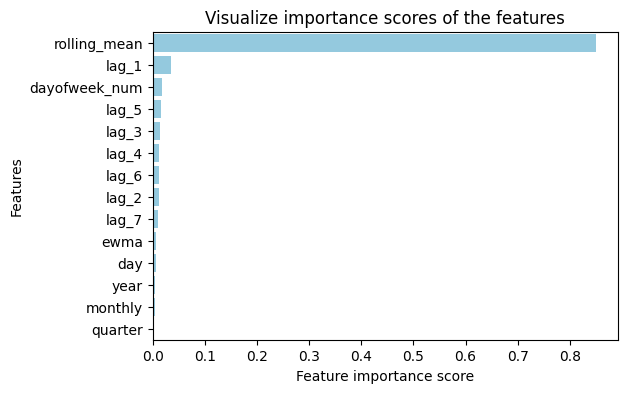

In [86]:
# to create a bar plot
f, ax = plt.subplots(figsize=(6, 4))
ax = sns.barplot(x='score', y='factor', data=importance_tbl, color='skyblue')
ax.set_title("Visualize importance scores of the features")
ax.set_yticklabels(importance_tbl['factor'])
ax.set_xlabel("Feature importance score")
ax.set_ylabel("Features")
plt.show()

In [87]:
# Import Libraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor

In [88]:
# list of models to be tested
models=[
        ('RandomForestRegressor', RandomForestRegressor(random_state=42)),
        ('SGDRegressor', SGDRegressor(random_state=42)),
        ('Ridge', Ridge(random_state=42)),
        ('Lasso', Lasso(random_state=42)),
        ('ElasticNet', ElasticNet(random_state=42)),
        ('SVR', SVR()),
        ('MLPRegressor', MLPRegressor(random_state=42)),
        ('DecisionTreeRegressor', DecisionTreeRegressor(random_state=42)),
        ('AdaBoostRegressor', AdaBoostRegressor(random_state=42)),
        ('BaggingRegressor', BaggingRegressor(random_state=42)),
        ('ExtraTreesRegressor', ExtraTreesRegressor(random_state=42)),
        ('GradientBoostingRegressor', GradientBoostingRegressor(random_state=42)),
        ('XGBRegressor', XGBRegressor(random_state=42)),
        ('KNeighborsRegressor', KNeighborsRegressor())
]

In [89]:
%%time
from sklearn.metrics import mean_absolute_error
from tqdm import tqdm, tqdm_gui
from sklearn.model_selection import cross_val_score
import random

## to evaluate the models using cross validation
model_names=[]
model_scores=[]
model_scores_mean=[]
model_scores_std=[]
cv=3
'''
'f1_micro':
Calculate metrics globally by counting the total true positives, false negatives and false positives.
'''
random.seed(42)
for name, model in tqdm(models):
    model_score = cross_val_score(model, final_train_X, final_train_y, scoring='neg_mean_absolute_error', cv=cv)
    model_score = -model_score
    model_names.append(name)
    model_scores.append(model_score)
    model_scores_mean.append(model_score.mean())
    model_scores_std.append(model_score.std())

100%|██████████| 14/14 [00:26<00:00,  1.93s/it]

CPU times: user 24.6 s, sys: 77.5 ms, total: 24.7 s
Wall time: 27 s


In [90]:
model_cv_results = pd.DataFrame({
    'Model':model_names,
    'Mean of MAE Score': model_scores_mean,
    'Std of MAE Score': model_scores_std
    })
round(model_cv_results.sort_values(by='Mean of MAE Score', ascending=True, ignore_index=True),4)

,Model,Mean of MAE Score,Std of MAE Score
0,XGBRegressor,3.400000e-02,2.400000e-03
1,RandomForestRegressor,3.500000e-02,2.700000e-03
2,ExtraTreesRegressor,3.510000e-02,2.500000e-03
3,Ridge,3.540000e-02,2.100000e-03
4,GradientBoostingRegressor,3.660000e-02,1.900000e-03
5,BaggingRegressor,3.730000e-02,1.900000e-03
6,AdaBoostRegressor,4.560000e-02,3.100000e-03
7,DecisionTreeRegressor,5.080000e-02,3.300000e-03
8,MLPRegressor,7.220000e-02,6.300000e-03
9,KNeighborsRegressor,8.810000e-02,1.070000e-02


Extra Trees Regressor is the best model among the 14 candidates. I wil tune the hyperparameters of ExtraTreesRegressor in the next step.

My strategy is to shrink hyperparameters space with the help of Bayesian Optimization, and then find the best set of hyperparameters using Grid Search.

#Bayesian Optimization (hyperopt)

Note: Reproducibility of BO tuning is NOT restricted by np.random.seed(), but the results from multiple executions of BO tuning are similar even though they are not identical. That being said, the readers run the following code snippets and may or may not get the same outcomes, however, the readers will draw the same conclusion as what I documented.

In [91]:
import hyperopt
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
import random

In [92]:
# Classifier:
def objective(space):
  clf = ExtraTreesRegressor(
      n_estimators = int(space['n_estimators']),
      max_depth = int(space['max_depth']),
      #max_samples = space['max_samples'],
      min_samples_split = int(space['min_samples_split']),
      min_samples_leaf = int(space['min_samples_leaf']),
      max_leaf_nodes = int(space['max_leaf_nodes'])
)

  return_val = cross_val_score(clf, final_train_X, final_train_y, cv=3, scoring='neg_mean_absolute_error')
  to_return = -return_val.mean()
  return {'loss':to_return, 'status': STATUS_OK }

1st tuning

In [93]:
space = {
    'n_estimators': hp.uniform('n_estimators', 0, 150),
    'max_depth': hp.quniform('max_depth', 3, 20, 1),
    #'max_samples': hp.uniform('max_samples', 0.5, 1.0),
    'min_samples_split': hp.quniform('min_samples_split', 2, 20, 1),
    'min_samples_leaf': hp.quniform('min_samples_leaf', 1, 10, 1),
    'max_leaf_nodes': hp.quniform('max_leaf_nodes', 10, 100, 1)
    }

In [94]:
%%time
random.seed = 42
trials = Trials()

best_hyperparams = fmin(fn = objective,
                        space = space,
                        algo = tpe.suggest,
                        max_evals = 3, # set it to 3 here
                        rstate = np.random.default_rng(seed=42),
                        trials = trials)

100%|██████████| 3/3 [00:02<00:00,  1.14trial/s, best loss: 0.03742788180930957]
CPU times: user 2.54 s, sys: 5.78 ms, total: 2.54 s
Wall time: 2.63 s


In [95]:
best_hyperparams_1st = best_hyperparams
best_hyperparams_1st

{'max_depth': np.float64(16.0),
 'max_leaf_nodes': np.float64(69.0),
 'min_samples_leaf': np.float64(9.0),
 'min_samples_split': np.float64(13.0),
 'n_estimators': np.float64(122.04831114604316)}

2nd tuning

In [96]:
from sklearn.metrics import mean_absolute_error
from tqdm import tqdm, tqdm_gui
from sklearn.model_selection import cross_val_score
import random

In [97]:
# 2nd space

space = {
    'n_estimators': hp.uniform('n_estimators', 120, 130),
    'max_depth': hp.quniform('max_depth', 15, 20, 1),
    #'max_samples': hp.uniform('max_samples', 0.5, 1.0),
    'min_samples_split': hp.quniform('min_samples_split', 12, 15, 1),
    'min_samples_leaf': hp.quniform('min_samples_leaf', 7, 10, 1),
    'max_leaf_nodes': hp.quniform('max_leaf_nodes', 65, 75, 1)
    }

In [98]:
%%time
random.seed = 42
trials = Trials()

best_hyperparams = fmin(fn = objective,
                        space = space,
                        algo = tpe.suggest,
                        max_evals = 3, # set it to 3 here
                        rstate = np.random.default_rng(seed=42),
                        trials = trials)

100%|██████████| 3/3 [00:09<00:00,  3.32s/trial, best loss: 0.03754414808932824]
CPU times: user 5.19 s, sys: 20.3 ms, total: 5.21 s
Wall time: 9.96 s


In [99]:
best_hyperparams_2nd = best_hyperparams
best_hyperparams_2nd

{'max_depth': np.float64(19.0),
 'max_leaf_nodes': np.float64(72.0),
 'min_samples_leaf': np.float64(10.0),
 'min_samples_split': np.float64(14.0),
 'n_estimators': np.float64(128.1365540764029)}

In [100]:
best_hyperparams_1st

{'max_depth': np.float64(16.0),
 'max_leaf_nodes': np.float64(69.0),
 'min_samples_leaf': np.float64(9.0),
 'min_samples_split': np.float64(13.0),
 'n_estimators': np.float64(122.04831114604316)}

3rd tuning

In [101]:
%%time

from sklearn.model_selection import GridSearchCV

param_grid = [{
    'n_estimators': [121, 128],
    'max_depth': [16, 19],
    'min_samples_split': [13, 14],
    'min_samples_leaf': [9, 10],
    'max_leaf_nodes': [69, 72]
}]

ET_grid = ExtraTreesRegressor(random_state=42)

grid_search = GridSearchCV(ET_grid, param_grid, cv=3,
                           scoring='neg_mean_absolute_error',
                           return_train_score=True)

grid_search.fit(final_train_X, final_train_y)

CPU times: user 47.5 s, sys: 112 ms, total: 47.6 s
Wall time: 50.8 s


GridSearchCV(cv=3, estimator=ExtraTreesRegressor(random_state=42),
             param_grid=[{'max_depth': [16, 19], 'max_leaf_nodes': [69, 72],
                          'min_samples_leaf': [9, 10],
                          'min_samples_split': [13, 14],
                          'n_estimators': [121, 128]}],
             return_train_score=True, scoring='neg_mean_absolute_error')

In [102]:
best_hyperparams_3rd = grid_search.best_params_
best_hyperparams_3rd

{'max_depth': 19,
 'max_leaf_nodes': 72,
 'min_samples_leaf': 9,
 'min_samples_split': 13,
 'n_estimators': 128}

In [103]:
grid_search.best_score_

np.float64(-0.03740963850631382)

In [104]:
my_model = ExtraTreesRegressor(
    n_estimators      = best_hyperparams_3rd['n_estimators'],
    max_depth         = best_hyperparams_3rd['max_depth'],
    min_samples_split = best_hyperparams_3rd['min_samples_split'],
    min_samples_leaf  = best_hyperparams_3rd['min_samples_leaf'],
    max_leaf_nodes    = best_hyperparams_3rd['max_leaf_nodes'],
    random_state      = 42
)

In [ ]:
import joblib

In [ ]:
# to save the model
joblib.dump(my_model, '/content/gdrive/My Drive/Colab Notebooks/Toronto_Ferry_Activity/my_model.pkl')

['/content/gdrive/My Drive/Colab Notebooks/WrittenTest_Manitoba/my_model.pkl']

In [ ]:
# to load model
#my_model = joblib.load('/content/gdrive/My Drive/Colab Notebooks/Toronto_Ferry_Activity/my_model.pkl')

Learning Curve Function

In [105]:
# to create a learning curve
def plot_learning_curve(model, X_train, y_train, X_val, y_val, M):
  train_errors, val_errors = [], []
  for m in range(10, X_train.shape[0], M):
    model.fit(X_train[:m], y_train[:m])
    y_train_predict = model.predict(X_train[:m])
    y_val_predict = model.predict(X_val)
    train_errors.append(mean_absolute_error(y_train[:m], y_train_predict))
    val_errors.append(mean_absolute_error(y_val, y_val_predict))

  plt.figure(figsize=(10,4))
  #plt.ylim([0.5, 1])
  plt.title('mean_absolute_error')
  plt.grid(True)
  plt.plot(train_errors, "r-+", linewidth=2, label='train')
  plt.plot(val_errors, "b-", linewidth=3, label='val')
  plt.legend(loc='upper right') # in case labels don't show up
  plt.show()

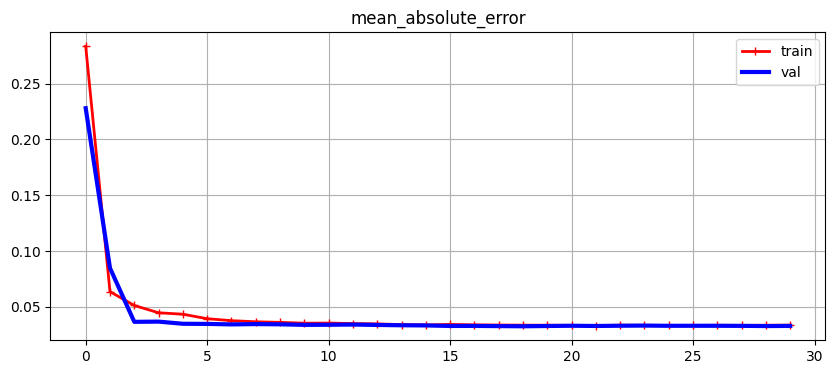

In [106]:
plot_learning_curve(my_model, final_train_X, final_train_y, final_val_X, final_val_y, M=100)

In [107]:
val_pred = my_model.predict(final_val_X)

In [108]:
mean_absolute_error(final_val_y, val_pred)

0.03290491605086568

# Prediction

In [138]:
final_test_X[0]

array([8.19915381e-01, 7.85391459e-01, 8.19506128e-01, 8.24533072e-01,
       7.86081178e-01, 9.08788423e-01, 8.42892900e-01, 8.17021479e-01,
       8.53043716e-01, 6.00000000e+00, 2.00000000e+00, 2.02400000e+03,
       7.00000000e+00, 4.00000000e+00])

In [152]:
# predict on test data
target_pred = my_model.predict(final_test_X)

In [153]:
target_pred[:10]

array([0.84701235, 0.85164955, 0.86780919, 0.80076706, 0.79854328,
       0.80620247, 0.82001751, 0.85354056, 0.89386805, 0.91166508])

In [154]:
pipeline.fit_transform(train_set_y)

array([[0.0732976 ],
       [0.0732976 ],
       [0.0732976 ],
       ...,
       [0.82169305],
       [0.80915145],
       [0.79176897]])

In [155]:
# to inverse the predictions to the original scale
target_predInv = pipeline.inverse_transform(target_pred.reshape(-1, 1)).astype(float)

In [143]:
target_predInv[:10]

array([[8.70301635],
       [8.74686855],
       [8.899684  ],
       [8.26569247],
       [8.24466298],
       [8.31709304],
       [8.44773657],
       [8.76475113],
       [9.14611257],
       [9.31441223]])

In [156]:
final_test_prediction = test[['Datetime', 'Sales Count']].copy()
final_test_prediction['Sales_Count_predicted'] = target_predInv
final_test_prediction

,Datetime,Sales Count,Sales_Count_predicted
0,2024-06-07,8.157084,8.703016
1,2024-06-08,9.140990,8.746869
2,2024-06-09,8.430763,8.899684
3,2024-06-10,8.311890,8.265692
4,2024-06-11,8.386401,8.244663
...,...,...,...
360,2025-06-02,8.595820,8.032693
361,2025-06-03,8.613049,8.049036
362,2025-06-04,8.598404,8.193316
363,2025-06-05,7.978996,8.341115


In [157]:
print(f"MAE from Extree Tree Model: {mae(final_test_prediction['Sales Count'], final_test_prediction['Sales_Count_predicted']):.2f}")
print(f"RMSE from Extree Tree Model: {rmse(final_test_prediction['Sales Count'], final_test_prediction['Sales_Count_predicted']):.2f}")
print(f"MSE from Extree Tree Model: {mse(final_test_prediction['Sales Count'], final_test_prediction['Sales_Count_predicted']):.2e}")
print(f"MAPE from Extree Tree Model: {mape(final_test_prediction['Sales Count'], final_test_prediction['Sales_Count_predicted']):.2e}")

MAE from Extree Tree Model: 0.31
RMSE from Extree Tree Model: 0.47
MSE from Extree Tree Model: 2.22e-01
MAPE from Extree Tree Model: 5.20e-02


# Comparison between Holt Winters(Baseline) and Extra Tree

Prediction of Holt Winters

In [148]:
%%time
sf_HW = StatsForecast(models=[HoltWinters(error_type = 'A', season_length = 365, alias="Forecast")], freq='D')
sf_HW.fit(df=tr)
Y_hat = sf_HW.forecast(df=tr, h=365, fitted=True, level=[])

full = pd.merge(te, Y_hat, on='ds', how='right')
full = full.drop(['unique_id_x','unique_id_y'], axis=1)
c_list = ['Forecast']
for c in c_list:
    full[c] = full[c].astype(float)
full

CPU times: user 24.4 s, sys: 164 ms, total: 24.6 s
Wall time: 31.9 s


,ds,y,Forecast
0,2024-06-07,8.157084,8.084927
1,2024-06-08,9.140990,8.145281
2,2024-06-09,8.430763,8.452685
3,2024-06-10,8.311890,8.482262
4,2024-06-11,8.386401,7.943195
...,...,...,...
360,2025-06-02,8.595820,8.313880
361,2025-06-03,8.613049,8.205685
362,2025-06-04,8.598404,8.368793
363,2025-06-05,7.978996,8.123539


In [149]:
print(f"MAE from Holt Winters Model: {mae(full['y'], full['Forecast']):.2f}")
print(f"RMSE from Holt Winters Model: {rmse(full['y'], full['Forecast']):.2f}")
print(f"MSE from Holt Winters Model: {mse(full['y'], full['Forecast']):.2e}")
print(f"MAPE from Holt Winters Model: {mape(full['y'], full['Forecast']):.2e}")

MAE from Holt Winters Model: 0.47
RMSE from Holt Winters Model: 0.68
MSE from Holt Winters Model: 4.61e-01
MAPE from Holt Winters Model: 8.11e-02


Comparison Table

In [150]:
metrics_comp = pd.DataFrame({'metric':['MAE', 'RMSE', 'MSE', 'MAPE'],
                             'Extree Tree':[f"{mae(final_test_prediction['Sales Count'], final_test_prediction['Sales_Count_predicted']):.2f}",
                                            f"{rmse(final_test_prediction['Sales Count'], final_test_prediction['Sales_Count_predicted']):.2f}",
                                            f"{mse(final_test_prediction['Sales Count'], final_test_prediction['Sales_Count_predicted']):.2e}",
                                            f"{mape(final_test_prediction['Sales Count'], final_test_prediction['Sales_Count_predicted']):.2e}"],
                             'Holt Winters':[f"{mae(full['y'], full['Forecast']):.2f}",
                                            f"{rmse(full['y'], full['Forecast']):.2f}",
                                            f"{mse(full['y'], full['Forecast']):.2e}",
                                            f"{mape(full['y'], full['Forecast']):.2e}"]})
metrics_comp

,metric,Extree Tree,Holt Winters
0,MAE,0.31,0.47
1,RMSE,0.47,0.68
2,MSE,2.22e-01,4.61e-01
3,MAPE,5.20e-02,8.11e-02


It would be easier to find out the comparison of the two model predictions by plotting two plots respectively:

a) Observed sales count and Extra Tree predictions

b) Observed sales count and Holt Winters predictions

In [158]:
final_test_prediction['Sales Count'] = np.exp(final_test_prediction['Sales Count'])
final_test_prediction['Sales_Count_predicted'] = np.exp(final_test_prediction['Sales_Count_predicted'])

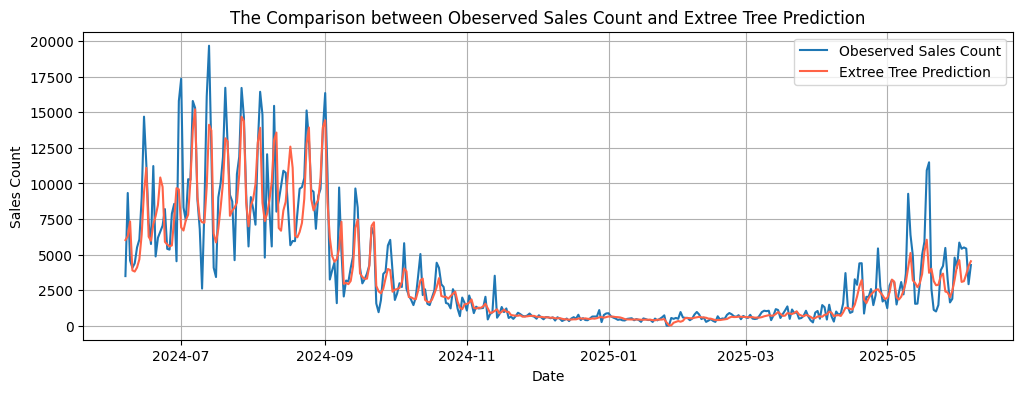

CPU times: user 218 ms, sys: 4.97 ms, total: 223 ms
Wall time: 224 ms


In [159]:
%%time
plt.figure(figsize=(12, 4))
plt.plot(df.index[-365:], df['Sales Count'].iloc[-365:], label='Obeserved Sales Count')
plt.plot(df.index[-365:], final_test_prediction['Sales_Count_predicted'], color='tomato', label='Extree Tree Prediction')
plt.xlabel('Date')
plt.ylabel('Sales Count')
plt.title('The Comparison between Obeserved Sales Count and Extree Tree Prediction')
plt.legend()
plt.grid(True)
# plt.xticks(rotation=45)
plt.show()

In [160]:
full['y'] = np.exp(full['y'])
full['Forecast'] = np.exp(full['Forecast'])
full.head(3)

,ds,y,Forecast
0,2024-06-07,3488.0,3245.181587
1,2024-06-08,9330.0,3447.075346
2,2024-06-09,4586.0,4687.640422


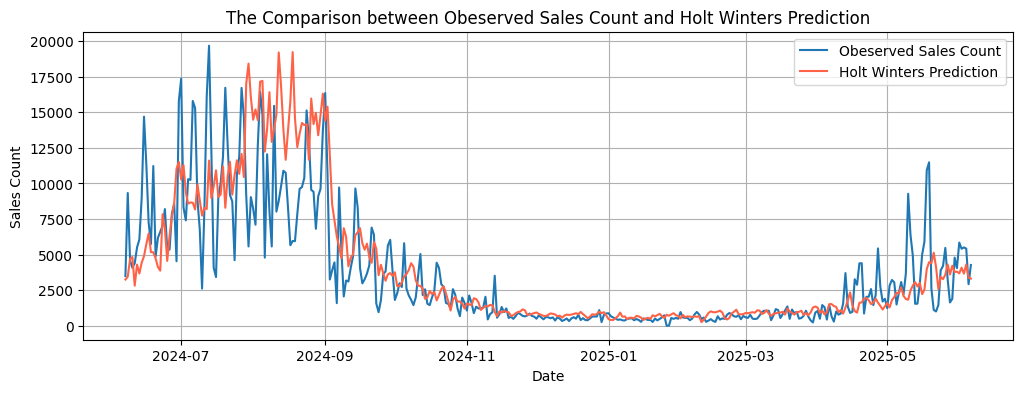

CPU times: user 389 ms, sys: 4.93 ms, total: 394 ms
Wall time: 412 ms


In [161]:
%%time
plt.figure(figsize=(12, 4))
plt.plot(df.index[-365:], df['Sales Count'].iloc[-365:], label='Obeserved Sales Count')
plt.plot(df.index[-365:], full['Forecast'], color='tomato', label='Holt Winters Prediction')
plt.xlabel('Date')
plt.ylabel('Sales Count')
plt.title('The Comparison between Obeserved Sales Count and Holt Winters Prediction')
plt.legend()
plt.grid(True)
# plt.xticks(rotation=45)
plt.show()

When I compare the 4 metrics from the two models, and compare the two plots, I can tell Extra Tree does a better job than Holt Winters.

my_model is ExtraTreesRegressor(

n_estimators = 128,

max_depth = 19,

min_samples_split = 13,

min_samples_leaf = 9,

max_leaf_nodes = 72,

random_state = 42

).